In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib # 日本語フォント対応
import seaborn as sns

In [2]:
# df.to_csv('/Users/balalala/Documents/GitHub/Consumption_Data/Data_time_series/en_setai_over2_monthly.csv', index=False)
df_share = pd.read_csv('/Users/balalala/Documents/GitHub/Consumption_Data/Data_time_series/en_share_over2_monthly.csv')

In [3]:
# Filter for rows where Medium (中分類) and Minor (小分類) are '-'
# This isolates the top-level "Major" rows

major_rows = df_share[ (df_share['Category level 1'] != '-') & (df_share['Category level 2'] == '-') & (df_share['Category level 3'] == '-') ]

major_dict = dict(zip(major_rows['Category level 1'], major_rows['Item']))
print(major_dict['1']) # Output: 食料

hierarchy = {}

# Iterate through every row
for index, row in df_share.iterrows():
    major_id = row['Category level 1']
    med_id = row['Category level 2']
    min_id = row['Category level 3']
    name = row['Item']

    # Skip header/garbage rows if any
    if major_id == '-': continue 

    # 1. Initialize Major Level
    # We use the ID as the key, but store the Name inside
    if major_id not in hierarchy:
        # Look up the major name from our simple dict
        major_name = major_dict.get(major_id, "他")
        hierarchy[major_id] = {'name': major_name, 'med': {}}

    # 2. Add Medium Level (if this row represents a Medium category or deeper)
    if med_id != '-':
        if med_id not in hierarchy[major_id]['med']:
             # Use the name if this is the defining row, otherwise generic placeholder until found
            hierarchy[major_id]['med'][med_id] = {'name': name, 'small': {}}
        
        # Update name if this is exactly the Medium definition row
        if min_id == '-':
            hierarchy[major_id]['med'][med_id]['name'] = name

    # 3. Add Minor Level (if this row represents a Minor category)
    if min_id != '-':
        # Add the minor category to the medium's children
        hierarchy[major_id]['med'][med_id]['small'][min_id] = name
# Usage:
# hierarchy[1]['children'][1]['name']  -> Access the name of Medium Category 1 inside Major 1
# Initialize the flat dictionary
# Key = Item Name (e.g., 'パン'), Value = Formatted String (e.g., '食料ーパン')

name_to_path_map = {}

# Iterate through the hierarchy
for major_id, major_data in hierarchy.items():
    major_name = major_data['name']
    
    # 1. Add the Major category itself (Optional, if needed)
    # name_to_path_map[major_name] = major_name
    
    # Check if 'med' exists
    if 'med' in major_data:
        for med_id, med_data in major_data['med'].items():
            med_name = med_data['name']
            
            # 2. Add Medium Category: Input '穀類' -> Output '食料ー穀類'
            name_to_path_map[med_name] = f"{major_name}ー{med_name}"
            
            # Check if 'small' exists
            if 'small' in med_data:
                for small_id, small_name in med_data['small'].items():
                    # 3. Add Small Category: Input 'パン' -> Output '食料ーパン'
                    # Note: Using strict user format "Major-Small". 
                    # If you wanted full path "Major-Med-Small", use: f"{major_name}ー{med_name}ー{small_name}"
                    name_to_path_map[small_name] = f"{major_name}ー{med_name}ー{small_name}"

# Check the result
print(name_to_path_map['bread']) 
# Output: '食料ーパン'

def get_category_path(item_name):
    return name_to_path_map.get(item_name, item_name) # Returns "他" if not found

print(get_category_path('bread'))

# --- Step 1: Flatten your hierarchy dictionary ---
# This converts: {'1': {'name': 'food', 'med': {'1': {'name': 'grains', 'small': {'1': 'rice'...
# To: {'rice': 'food', 'bread': 'food', ...}

category_map = {}

for l1_id, l1_info in hierarchy.items():
    l1_name = l1_info['name']
    for l2_id, l2_info in l1_info['med'].items():
        # Option A: Map to Level 1 (Food vs Transport)
        # Option B: Map to Level 2 (Grains vs Meat)
        # Let's map to Level 1 for a high-level systemic view
        for l3_id, l3_name in l2_info['small'].items():
            category_map[l3_name] = l1_name

# Convert to a Series for easy grouping
category_series = pd.Series(category_map)
category_series

food
foodーgrainsーbread
foodーgrainsーbread


rice                                                                        food
bread                                                                       food
noodles                                                                     food
other grains                                                                food
fresh seafood                                                               food
salted and dried seafood                                                    food
Fish paste products                                                         food
Other processed seafood products                                            food
fresh meat                                                                  food
processed meat                                                              food
milk                                                                        food
dairy products                                                              food
egg                         

In [4]:
# Dataframe for 3 levels of category hierarchy

c1 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']=='-') & (df_share['Category level 3']=='-')]

c2 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']!='-') & (df_share['Category level 3']=='-')]

c3 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']!='-') & (df_share['Category level 3']!='-')]

In [5]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from scipy.stats import zscore

def prep_data_for_stl(raw_df: pd.DataFrame, meta_col_count: int = 3) -> pd.DataFrame:
    """
    Cleans raw DataFrame and transposes it into a Time x Items format.
    """
    # 1. Extract and Transpose
    df_ts = raw_df.set_index('Item').iloc[:, meta_col_count:]
    df_t = df_ts.T

    # 2. Index Formatting
    df_t.index = pd.to_datetime(df_t.index)
    df_t = df_t.sort_index()

    # 3. Type Casting & Handle Missing Data (STL requires no NaNs)
    df_t = df_t.astype(np.float64)
    # df_t = df_t.ffill().bfill() # Forward/backward fill any missing percentages
    
    return df_t

def get_residuals(series: pd.Series, period: int = 12) -> pd.Series:
    """
    Extracts the residual component from a time series using STL.
    """
    # robust=True handles outliers (like COVID-19 anomalies) better
    res = STL(series, period=period, robust=True).fit()
    return res.resid


In [46]:
# STEP 1: Clean and Transpose raw consumption data
df_clean = prep_data_for_stl(c1, meta_col_count=3)

# STEP 2: Apply STL to get the Residuals (Deviations from trend/seasonality)
df_residuals = df_clean.apply(get_residuals, period=12)

# STEP 3: Apply Min-Max Normalization
df_res_norm = df_residuals.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

# STEP 4: Output as Markdown
# Using .to_markdown() converts the dataframe head into a formatted markdown table
markdown_output = df_res_norm.head().to_markdown()
print(markdown_output)
print(df_res_norm.shape)

|                     |     food |   residence |   Utilities/Water |   Furniture/household supplies |   clothing and footwear |   health care |   Transportation/Communication |   education |   educational entertainment |   Other consumption expenditure |
|:--------------------|---------:|------------:|------------------:|-------------------------------:|------------------------:|--------------:|-------------------------------:|------------:|----------------------------:|--------------------------------:|
| 2000-01-01 00:00:00 | 0.410179 |    0.484911 |          0.449561 |                       0.287333 |                0.797492 |      0.575891 |                       0.553131 |    0.478427 |                    0.501358 |                        0.413295 |
| 2000-02-01 00:00:00 | 0.387601 |    0.456422 |          0.489107 |                       0.258839 |                0.749468 |      0.5884   |                       0.584449 |    0.42593  |                    0.533485 |               

In [44]:
df_clean

Item,food,residence,Utilities/Water,Furniture/household supplies,clothing and footwear,health care,Transportation/Communication,education,educational entertainment,Other consumption expenditure
2000-01-01,23.7645,5.3482,8.0602,3.1668,6.3310,3.5337,10.1369,4.0475,10.2322,25.3791
2000-02-01,25.2213,6.3489,8.8343,3.1679,4.9542,4.0559,10.6794,4.9821,10.2307,21.5249
2000-03-01,23.7746,5.4873,7.5544,3.2960,5.4768,3.5090,11.6589,5.2809,10.7383,23.2241
2000-04-01,23.0688,5.6121,6.8332,2.8773,5.3771,3.3557,12.3349,7.1729,10.1844,23.1839
2000-05-01,26.3850,6.2392,6.8300,3.6543,6.0642,3.6734,11.6957,3.7308,10.9617,20.7661
...,...,...,...,...,...,...,...,...,...,...
2025-07-01,30.6293,6.5834,6.5994,5.2876,3.2840,5.4708,15.2479,2.5918,10.0146,14.2914
2025-08-01,32.6275,6.0243,6.6855,4.4971,2.6648,4.9488,13.5577,2.3511,11.9098,14.7332
2025-09-01,30.7156,5.0565,7.3117,4.0285,2.4171,5.2847,15.5883,4.0189,10.1206,15.4584
2025-10-01,30.7464,5.9598,7.0632,3.8423,3.3085,5.5130,13.8462,4.4246,10.1596,15.1363


In [29]:
import pandas as pd
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view


def calculate_relaxation_times(df, threshold_multiplier=0.5):
    """
    Calculate relaxation times (tau) for price shocks across commodity categories.
    
    For each category, identifies shock events where the deviation from a 12-month
    moving average exceeds a threshold, then estimates the exponential decay rate
    back to equilibrium using AR(1) regression.
    
    Parameters
    ----------
    df : pd.DataFrame
        Time series with a datetime column 'Item' (or DatetimeIndex) and
        one column per commodity category.
    threshold_multiplier : float, default 1.5
        Shocks are defined as deviations exceeding
        threshold_multiplier * 1.2 * std(residuals).
    
    Returns
    -------
    pd.DataFrame
        One row per detected shock episode with columns:
        Category, Peak_Date, Return_Date, Peak_Deviation, C_Coefficient,
        Relaxation_Time_tau.
    """
    # --- 0. Preprocessing: ensure DatetimeIndex ---
    if "Item" in df.columns:
        df["Item"] = pd.to_datetime(df["Item"])
        df = df.set_index("Item")

    # --- 1. Compute relative deviation from 12-month centered MA ---
    df_ma = df.rolling(window=3, center=True).mean()
    # Vectorised residual: (actual - MA) / MA
    df_y = df.sub(df_ma).div(df_ma)

    results = []

    for category in df_y.columns:
        y = df_y[category].dropna()
        vals = y.values
        dates = y.index
        n = len(vals)
        if n < 3:
            continue

        # --- 2. Shock threshold ---
        threshold = threshold_multiplier  * np.nanstd(vals, ddof=1)
        is_shock = np.abs(vals) > threshold

        # --- 3. State-machine: detect shock peaks and zero-crossings ---
        in_shock = False
        peak_idx = 0
        peak_val = 0.0

        for i in range(n):
            v = vals[i]

            if is_shock[i]:
                if not in_shock:
                    in_shock = True
                    peak_idx = i
                    peak_val = v
                elif abs(v) > abs(peak_val):
                    peak_idx = i
                    peak_val = v

            elif in_shock:
                # Zero-crossing check (sign reversal or exact zero)
                if v * peak_val <= 0:
                    window = vals[peak_idx : i + 1]

                    if len(window) >= 3:
                        # --- 4. AR(1) without intercept: y_{t+1} = C * y_t ---
                        x = window[:-1]
                        y_next = window[1:]
                        ss_xx = x @ x
                        if ss_xx > 0:
                            C = (x @ y_next) / ss_xx  # OLS closed-form
                            tau = -1.0 / np.log(C) if 0 < C < 1 else np.nan

                            results.append({
                                "Category": category,
                                "Peak_Date": dates[peak_idx].strftime("%Y-%m"),
                                "Return_Date": dates[i].strftime("%Y-%m"),
                                "Peak_Deviation": round(peak_val, 4),
                                "C_Coefficient": round(C, 4),
                                "Relaxation_Time_tau": round(tau, 2),
                            })

                    in_shock = False
                    peak_val = 0.0

    return pd.DataFrame(results)


# ========== Usage ==========
final_df = calculate_relaxation_times(df_residuals, threshold_multiplier=0.5)
final_df

,Category,Peak_Date,Return_Date,Peak_Deviation,C_Coefficient,Relaxation_Time_tau
0,food,2002-03,2002-05,-142.3094,0.0051,0.19
1,food,2002-11,2003-03,-697.2294,0.0008,0.14
2,food,2003-12,2004-02,-102.0288,0.0732,0.38
3,food,2004-06,2004-08,38.3054,0.0028,0.17
4,food,2011-05,2011-08,52.7536,0.0030,0.17
...,...,...,...,...,...,...
68,Other consumption expenditure,2003-11,2004-01,-13.3532,0.0184,0.25
69,Other consumption expenditure,2005-04,2005-06,-76.0312,0.0132,0.23
70,Other consumption expenditure,2005-09,2006-03,-154.7990,0.0213,0.26
71,Other consumption expenditure,2016-08,2016-10,10.3869,0.1431,0.51


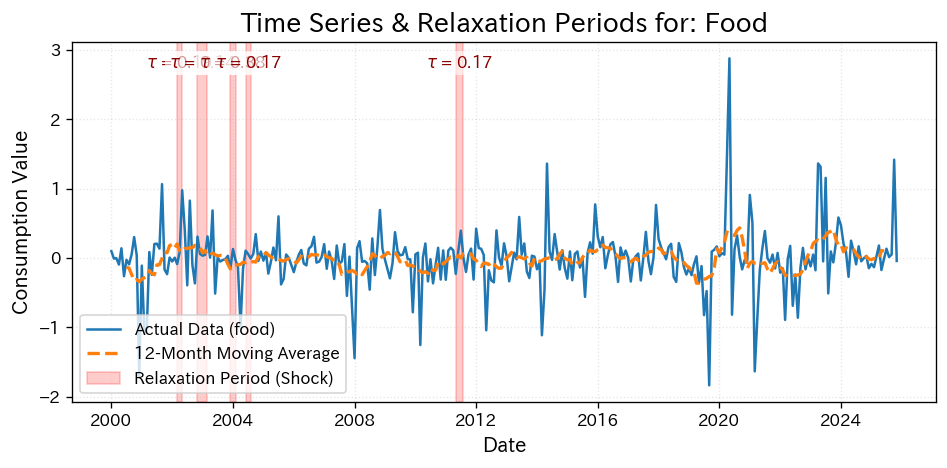

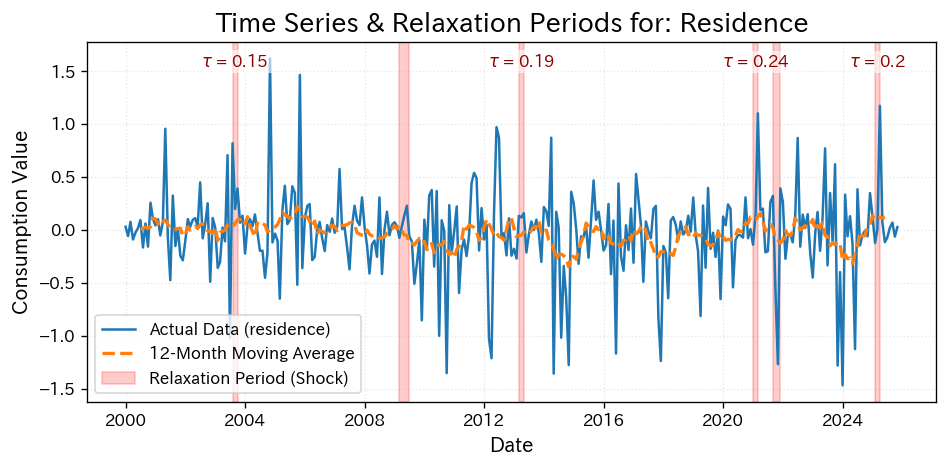

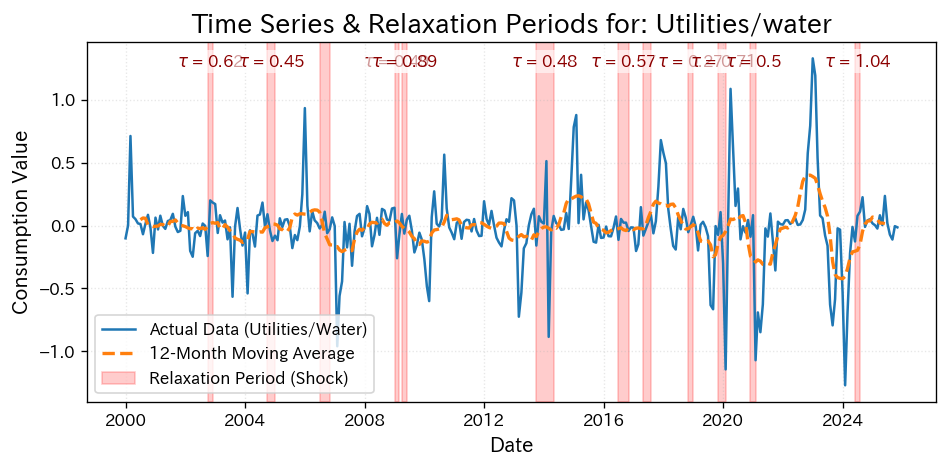

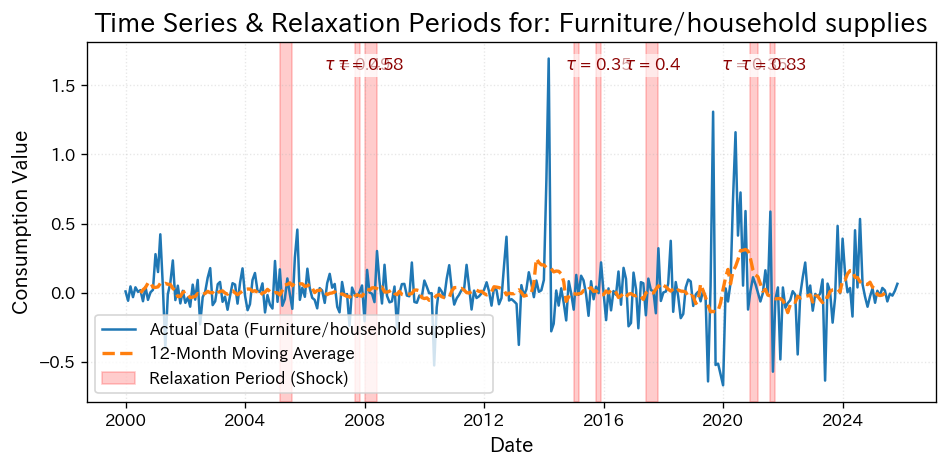

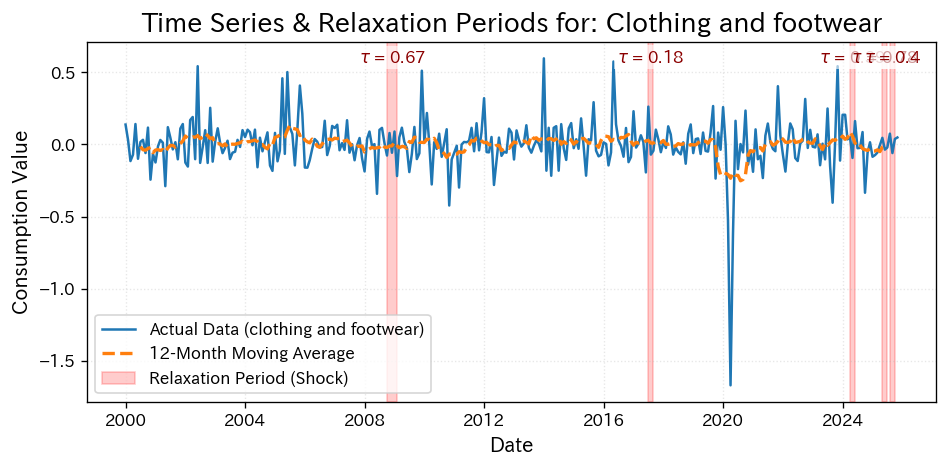

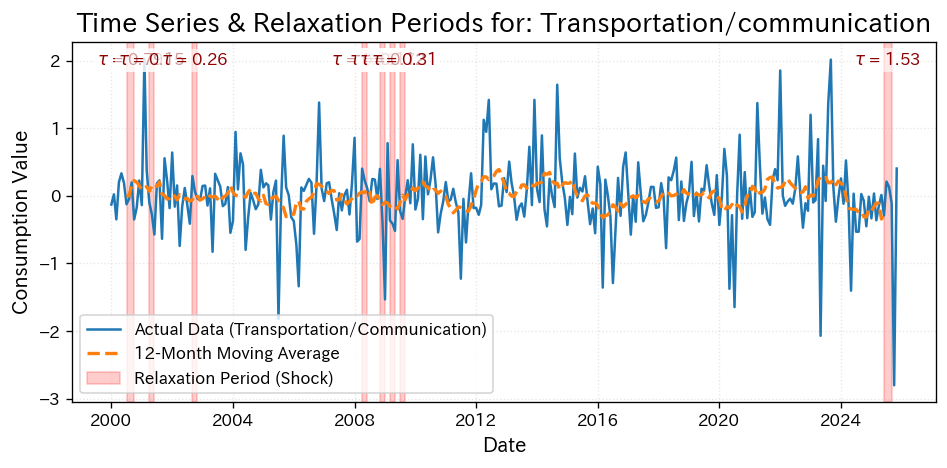

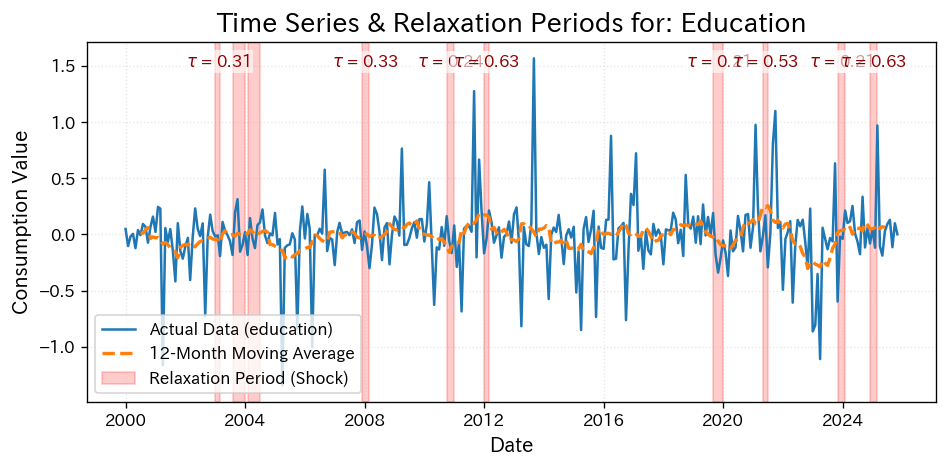

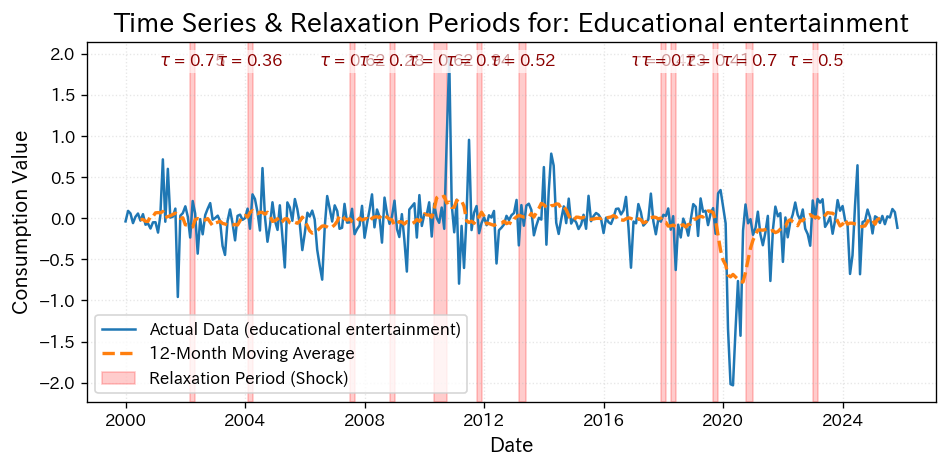

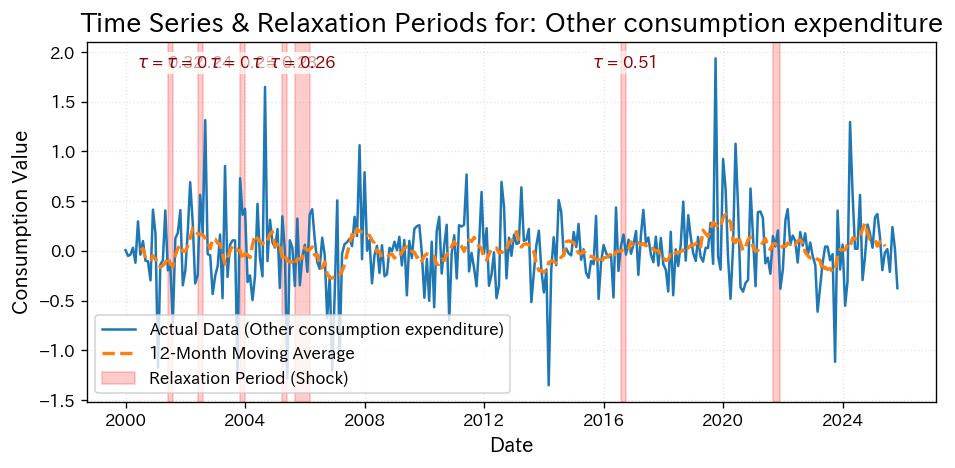

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_results_with_ax(df_clean, final_df, category):
    """
    Visualize the actual time series, moving average, and shock/relaxation 
    periods for a specific category using the calculated final_df.
    """
    # 1. Prepare the original time series data
    df = df_clean.copy()
    if 'Item' in df.columns:
        df['Item'] = pd.to_datetime(df['Item'])
        df.set_index('Item', inplace=True)
    
    # Ensure the index is DatetimeIndex just in case
    df.index = pd.to_datetime(df.index)
        
    actual = df[category]
    # Calculate the 12-month centered moving average (baseline)
    ma = actual.rolling(window=12, center=True).mean()
    
    # 2. Filter the results dataframe for the target category
    # Make a copy to avoid SettingWithCopyWarning
    cat_results = final_df[final_df['Category'] == category].copy() 
    
    # 3. Create the figure and axis objects
    fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
    
    # Plot Actual Data
    ax.plot(actual.index, actual, label=f'Actual Data ({category})', 
            color='#1f77b4', linewidth=1.5)
    
    # Plot Moving Average
    ax.plot(ma.index, ma, label='12-Month Moving Average', 
            color='#ff7f0e', linestyle='--', linewidth=2)
    
    # 4. Highlight the shock/relaxation periods from final_df
    added_label = False # Flag to avoid duplicate legend entries
    
    for _, row in cat_results.iterrows():
        # Convert string dates back to datetime objects for plotting
        start_date = pd.to_datetime(row['Peak_Date'])
        end_date = pd.to_datetime(row['Return_Date'])
        tau_val = row['Relaxation_Time_tau']
        
        # Add legend label only for the first shaded area
        label = 'Relaxation Period (Shock)' if not added_label else ""
        
        # Draw the shaded region (vertical span)
        ax.axvspan(start_date, end_date, color='red', alpha=0.2, label=label)
        added_label = True
        
        # Optional: Annotate the tau value directly above the shaded area
        # Calculate the midpoint of the shaded area for text placement
        mid_date = start_date + (end_date - start_date) / 2
        # Place text slightly below the maximum y-value of the plot
        y_max = actual.max()
        
        if pd.notna(tau_val):
            ax.text(mid_date, y_max * 0.95, f'$\\tau$ = {tau_val}', 
                    horizontalalignment='center', 
                    color='darkred', 
                    fontweight='bold',
                    fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))
            
    # 5. Format the axes and figure
    ax.set_title(f'Time Series & Relaxation Periods for: {category.capitalize()}', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Consumption Value', fontsize=12)
    
    # Configure the legend
    ax.legend(loc='lower left', fontsize=10)
    
    # Add a subtle grid
    ax.grid(True, alpha=0.3, linestyle=':')
    
    # Adjust layout to prevent clipping
    fig.tight_layout()
    
    # Display the plot
    plt.show()

# ==========================================
# Example Usage:
# Assuming 'df_residuals' is your original wide dataframe
# and 'final_df' is the dataframe output from the calculation step.
for category in final_df['Category'].unique():
    plot_results_with_ax(df_residuals, final_df, category)

# ==========================================

# Time-Series Structural Change Analysis

This pipeline evaluates whether a specific time-series category follows a stable, predictable pattern or if it has undergone fundamental "regime shifts" over time. The analysis is broken down into three main statistical and visual steps.

## 1. Stationarity Testing (ADF Test)
We use the **Augmented Dickey-Fuller (ADF) test** to determine the "memory" of the system.
* **Objective:** To check if the system returns to a steady state after a shock, or if shocks permanently alter the trajectory.
* **Hypotheses:** * **Null Hypothesis ($H_0$):** The data has a unit root (non-stationary). Shocks accumulate permanently, and there is no fixed mean.
  * **Alternative Hypothesis ($H_1$):** The data is stationary ($p < 0.05$). The system has a steady state, and shocks are eventually absorbed.

## 2. Structural Break Detection (PELT Algorithm)
To identify exactly *when* fundamental shifts occurred, we use the `ruptures` library.
* **Method:** The **PELT (Pruned Exact Linear Time)** algorithm is applied using an L2 cost model (`model="l2"`).
* **Objective:** To detect points in time where the mean of the series jumps significantly, indicating a transition from one steady state (regime) to another.
* **Tuning:** A penalty value (`pen=15`) is used to control sensitivity. Higher penalties yield fewer, more significant breakpoints.

## 3. Visualization & Interpretation
The final step generates a plot to contextualize the statistical findings:
* **Raw Data:** The original time-series is plotted as a line graph.
* **Regime Highlighting:** The timeline is divided into color-coded vertical bands based on the detected breakpoints.
* **Local Means:** A solid horizontal line is drawn across each segment to represent the "local steady state" (mean) of that specific regime. 

By combining the ADF test with breakpoint detection, we can visually and statistically confirm if and when the underlying behavior of the data changed permanently.

food
========== 【FOOD】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.0000
结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。

[2] 结构突变检测结果:
检测到 6 次发生'回不去'的结构性突变，时间点分别在: 2000-11, 2001-04, 2019-03, 2020-01, 2020-06, 2022-12


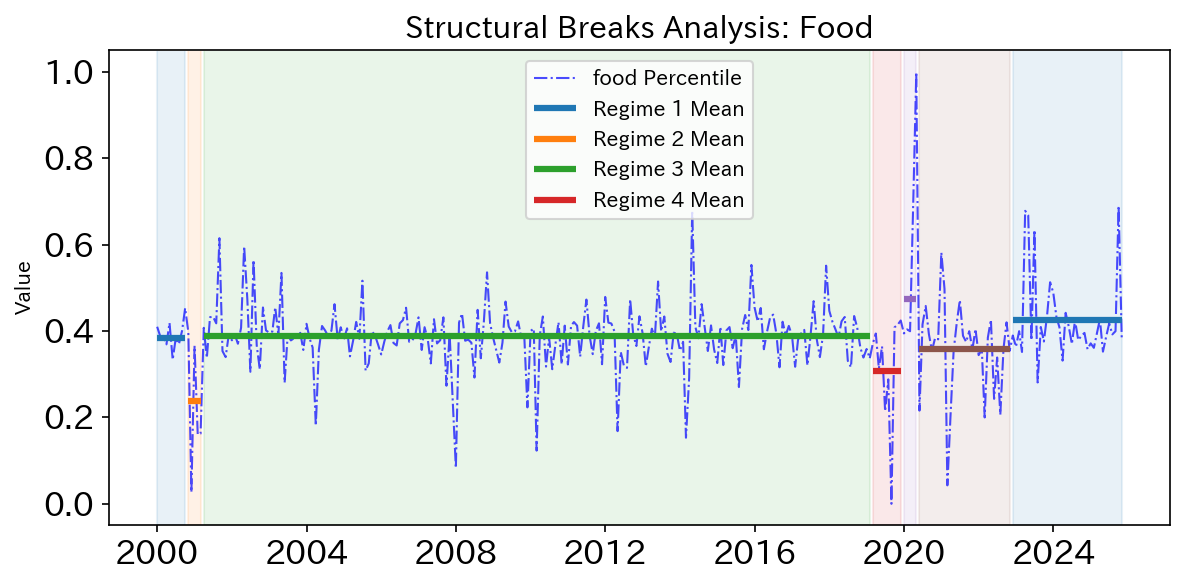

residence
========== 【RESIDENCE】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.0000
结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。

[2] 结构突变检测结果:
检测到 8 次发生'回不去'的结构性突变，时间点分别在: 2009-08, 2010-11, 2014-08, 2015-01, 2017-12, 2018-05, 2023-10, 2024-08


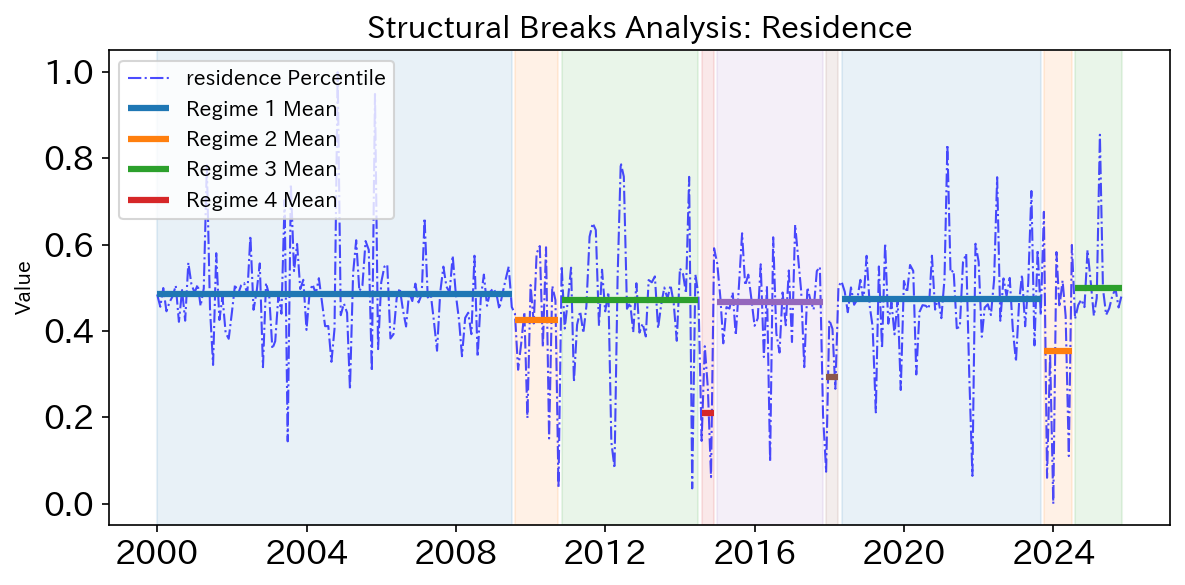

Utilities/Water
========== 【UTILITIES/WATER】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.0000
结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。

[2] 结构突变检测结果:
检测到 11 次发生'回不去'的结构性突变，时间点分别在: 2007-02, 2007-07, 2015-01, 2015-06, 2017-12, 2018-05, 2020-11, 2021-09, 2022-12, 2023-05, 2024-08


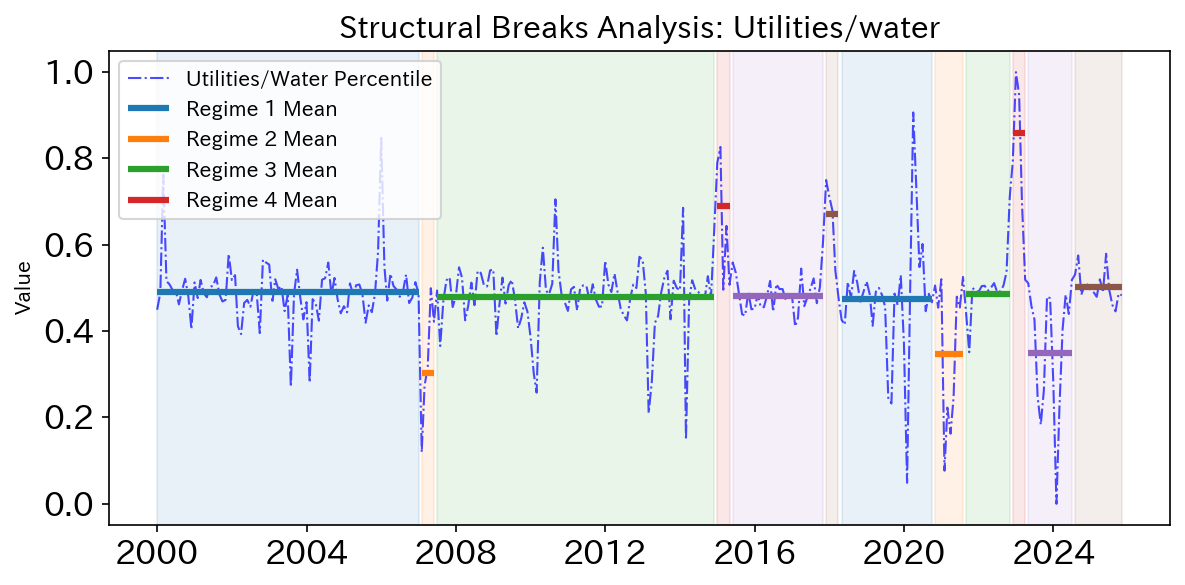

Furniture/household supplies
========== 【FURNITURE/HOUSEHOLD SUPPLIES】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.0000
结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。

[2] 结构突变检测结果:
检测到 4 次发生'回不去'的结构性突变，时间点分别在: 2013-10, 2014-08, 2020-06, 2020-11


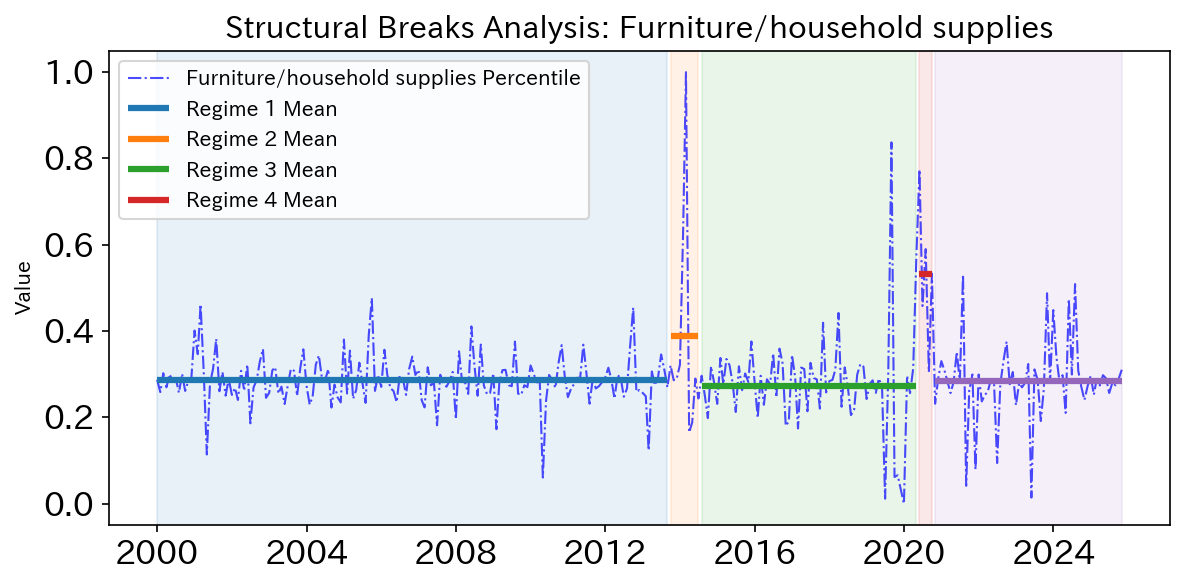

clothing and footwear
========== 【CLOTHING AND FOOTWEAR】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.0000
结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。

[2] 结构突变检测结果:
检测到 2 次发生'回不去'的结构性突变，时间点分别在: 2020-01, 2020-06


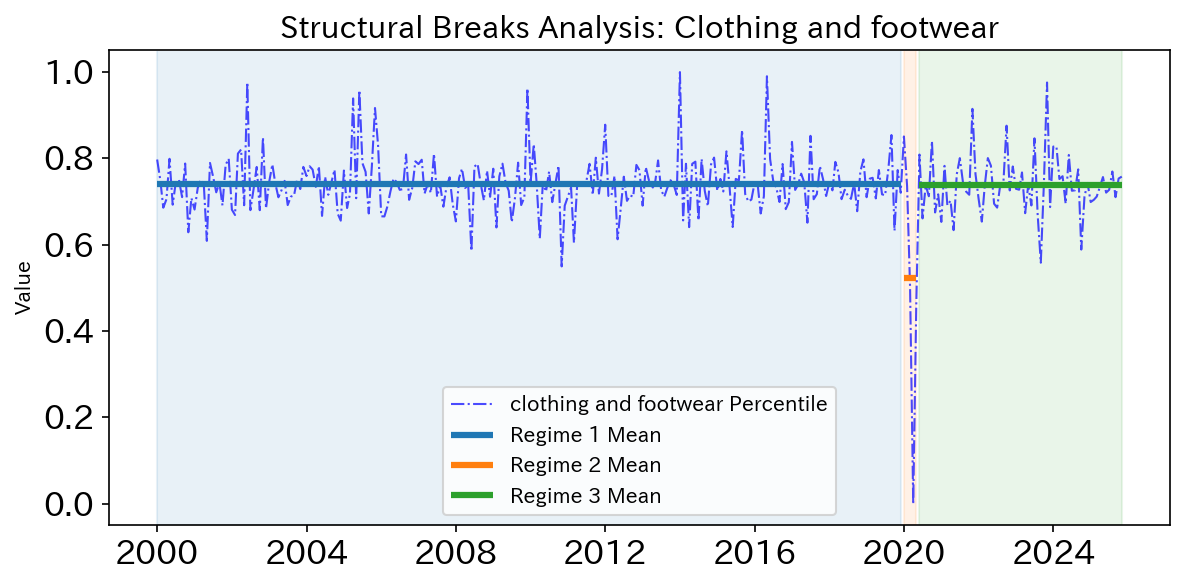

Transportation/Communication
========== 【TRANSPORTATION/COMMUNICATION】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.0000
结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。

[2] 结构突变检测结果:
检测到 4 次发生'回不去'的结构性突变，时间点分别在: 2012-02, 2015-01, 2021-04, 2023-10


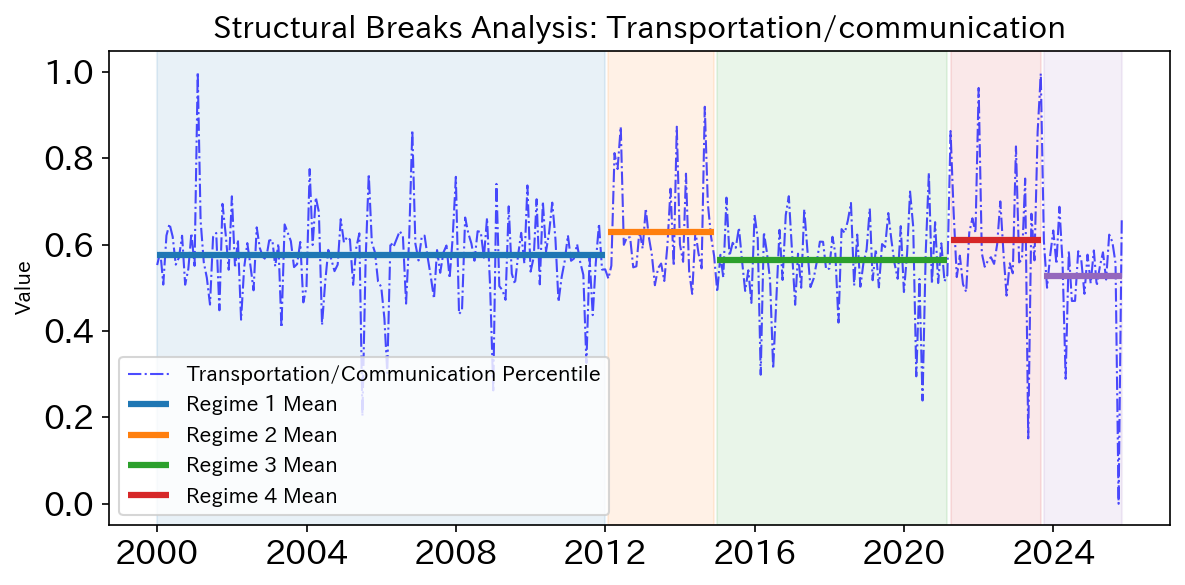

education
========== 【EDUCATION】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.0000
结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。

[2] 结构突变检测结果:
检测到 4 次发生'回不去'的结构性突变，时间点分别在: 2011-09, 2012-02, 2022-12, 2023-05


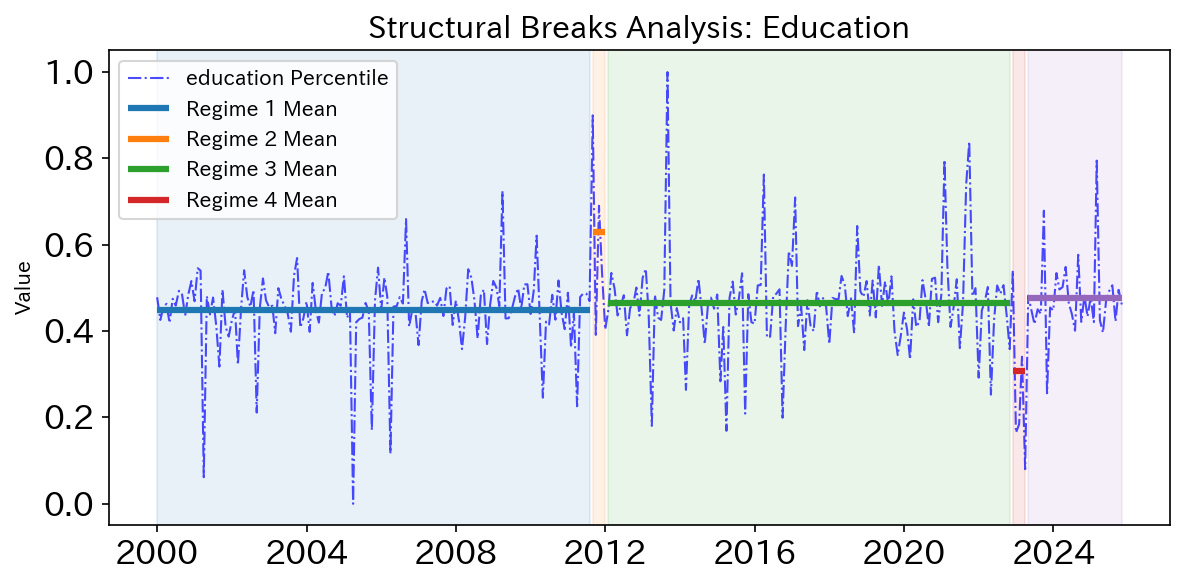

educational entertainment
========== 【EDUCATIONAL ENTERTAINMENT】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.0000
结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。

[2] 结构突变检测结果:
检测到 2 次发生'回不去'的结构性突变，时间点分别在: 2020-01, 2020-11


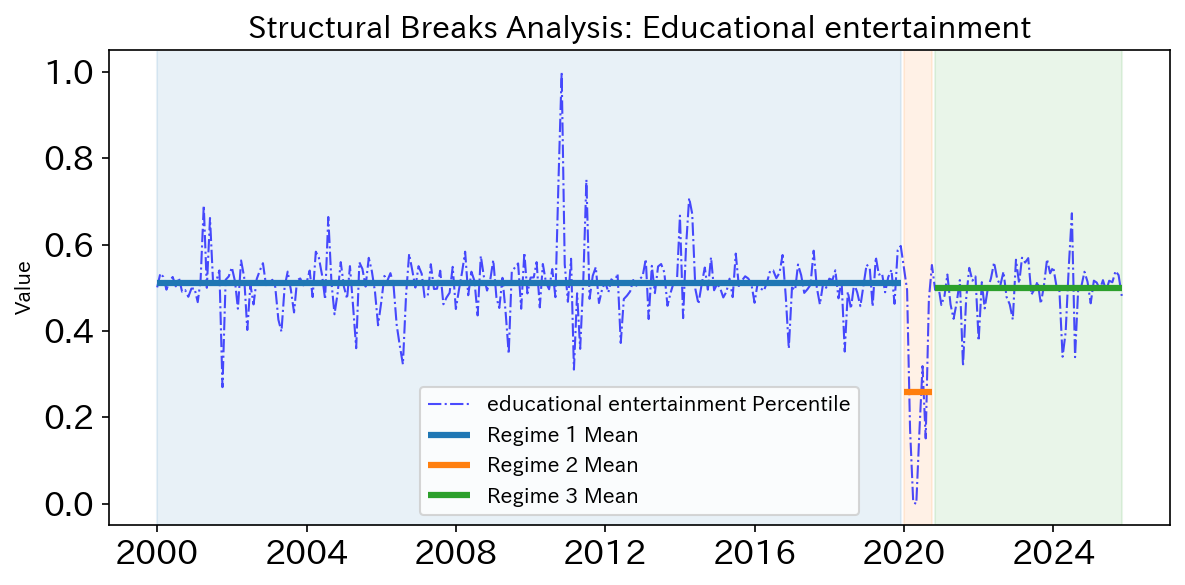

Other consumption expenditure
========== 【OTHER CONSUMPTION EXPENDITURE】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.0001
结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。

[2] 结构突变检测结果:
检测到 5 次发生'回不去'的结构性突变，时间点分别在: 2006-09, 2007-02, 2019-08, 2022-12, 2024-03


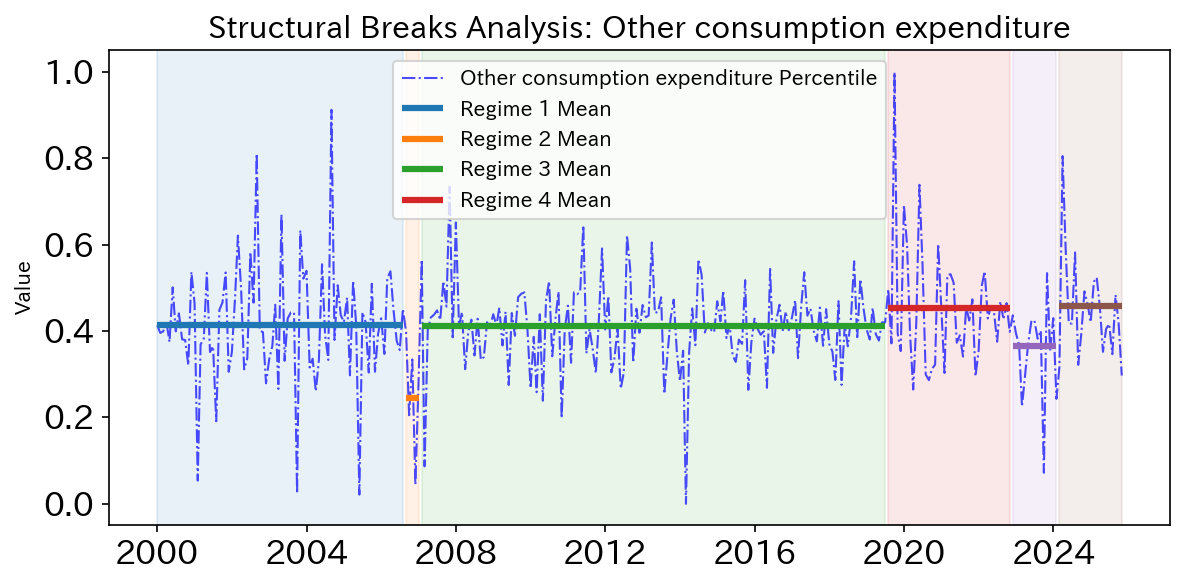

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import ruptures as rpt

def analyze_structural_changes(df_clean, category):
    """
    对单一消费类别进行平稳性检验与结构突变检测
    """
    # 0. 数据准备
    df = df_clean.copy()
    if 'Item' in df.columns:
        df['Item'] = pd.to_datetime(df['Item'])
        df.set_index('Item', inplace=True)
        
    series = df[category].dropna()
    
    print(f"========== 【{category.upper()}】 结构演变分析 ==========")
    
    # ---------------------------------------------------------
    # 1. 回答猜想一：定常状态存不存在？ (ADF 检验)
    # ---------------------------------------------------------
    # H0 (原假设): 存在单位根（非平稳，不存在定常状态，冲击会累积）
    # H1 (备择假设): 数据是平稳的（存在定常状态，冲击会被缓和）
    adf_result = adfuller(series, autolag='AIC')
    p_value = adf_result[1]
    
    print("\n[1] ADF 平稳性检验结果:")
    print(f"p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。")
    else:
        print("结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。")

    # ---------------------------------------------------------
    # 2. 回答猜想二与三：寻找突变点 (Ruptures PELT 算法)
    # ---------------------------------------------------------
    # series 转为 numpy array
    signal = series.values.reshape(-1, 1)
    
    # 使用 PELT 算法寻找均值突变点 (model="l2" 寻找均值跳跃)
    # pen 是惩罚系数，数值越大找出的突变点越少，可根据数据敏感度调整
    algo = rpt.Pelt(model="l2").fit(signal)
    result_breakpoints = algo.predict(pen=0.04)
    
    # 打印突变点对应的时间
    print("\n[2] 结构突变检测结果:")
    break_dates = []
    for idx in result_breakpoints[:-1]: # 最后一个是数据结尾，忽略
        date_str = series.index[idx].strftime('%Y-%m')
        break_dates.append(date_str)
    
    if len(break_dates) > 0:
        print(f"检测到 {len(break_dates)} 次发生'回不去'的结构性突变，时间点分别在: {', '.join(break_dates)}")
    else:
        print("未检测到显著的结构性突变点。")

    # ---------------------------------------------------------
    # 3. 可视化：看突变与累积是否同时存在
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
    
    # 画原始数据
    ax.plot(series.index, series.values, label=f'{category} Percentile', 
            color='blue', linewidth=1, linestyle='-.', alpha=0.7)
    
    # 画突变区间及分段均值
    start_idx = 0
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for i, bp in enumerate(result_breakpoints):
        end_idx = bp - 1 if bp < len(series) else len(series) - 1
        
        segment_data = series.iloc[start_idx:end_idx]
        segment_mean = segment_data.mean()
        
        # 填充背景色区分不同 Regime (状态)
        ax.axvspan(series.index[start_idx], series.index[end_idx], 
                   color=colors[i % len(colors)], alpha=0.1)
        
        # 画出这段时间内的“局部均值线” (代表这一个 Regime 的稳态)
        ax.hlines(y=segment_mean, xmin=series.index[start_idx], xmax=series.index[end_idx], 
                  color=colors[i % len(colors)], linewidth=3, linestyle='-', 
                  label=f'Regime {i+1} Mean' if i < 4 else "") # 限制图例数量
        
        start_idx = bp
        
    ax.set_title(f'Structural Breaks Analysis: {category.capitalize()}', fontsize=15, fontweight='bold')
    ax.set_ylabel('Value')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

# 调用示例：
for cat in final_df['Category'].unique():
    print(cat)
    analyze_structural_changes(df_res_norm, cat)

food
========== 【FOOD】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.9515
结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。

[2] 结构突变检测结果:
检测到 2 次发生'回不去'的结构性突变，时间点分别在: 2015-06, 2023-05


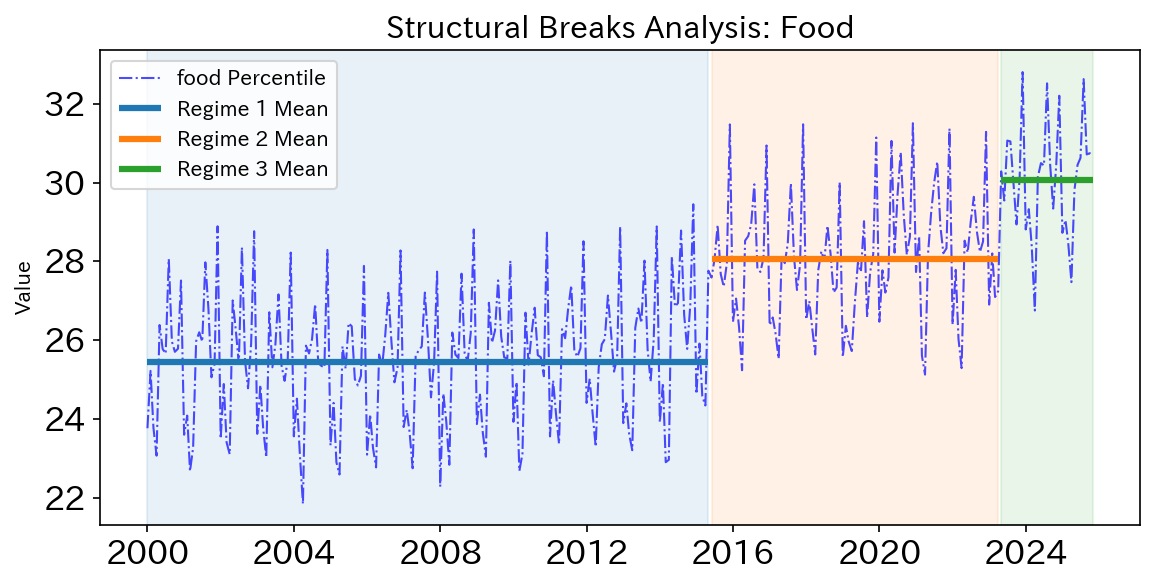

residence
========== 【RESIDENCE】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.2164
结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。

[2] 结构突变检测结果:
未检测到显著的结构性突变点。


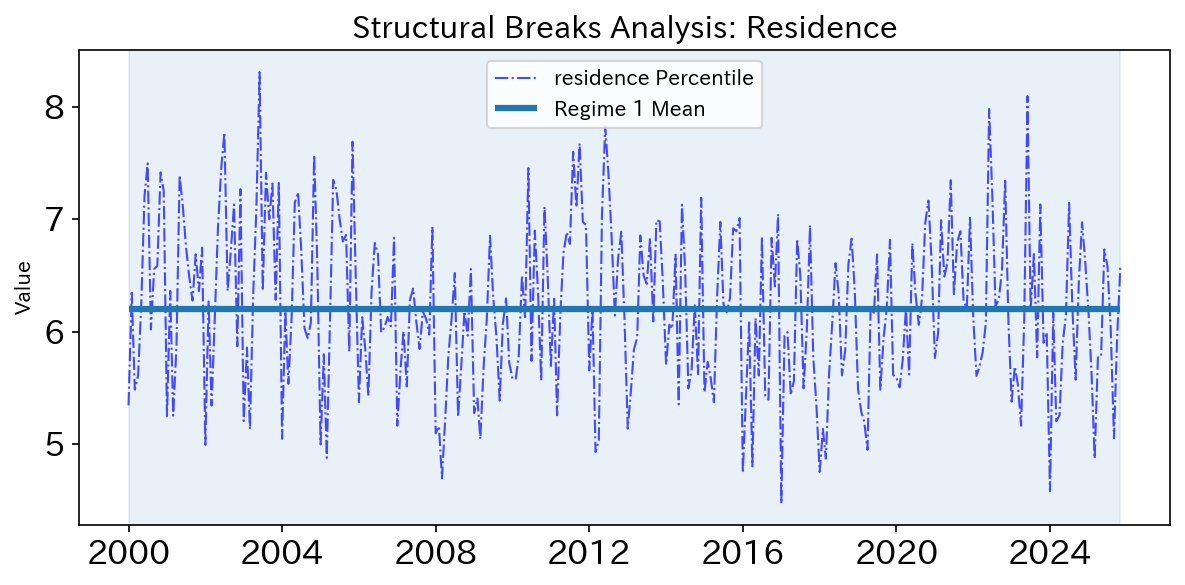

Utilities/Water
========== 【UTILITIES/WATER】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.1389
结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。

[2] 结构突变检测结果:
检测到 3 次发生'回不去'的结构性突变，时间点分别在: 2005-11, 2022-12, 2023-05


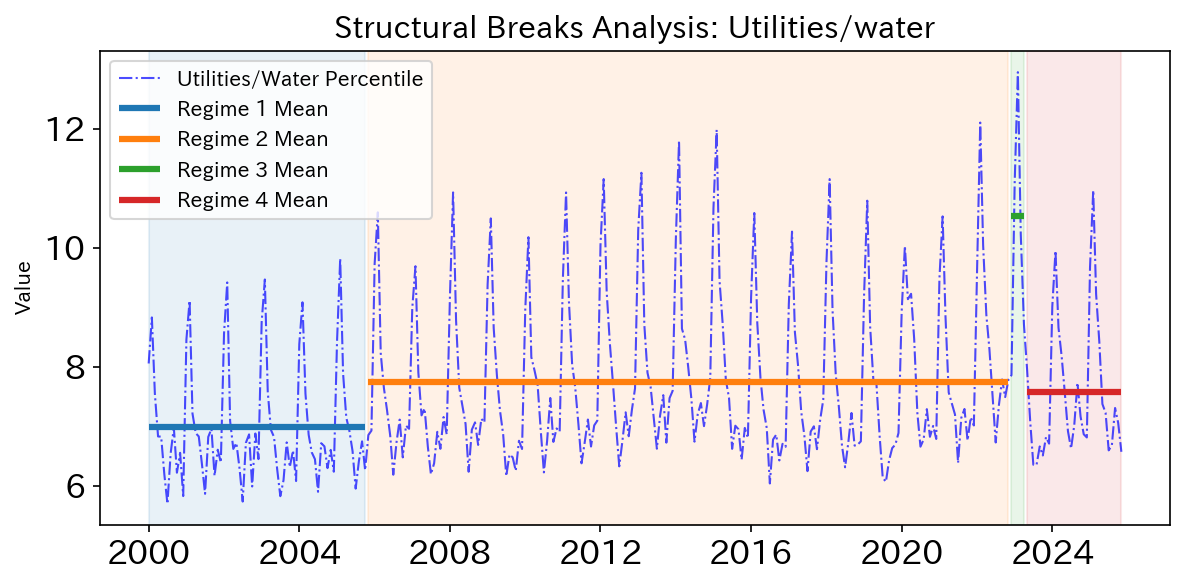

Furniture/household supplies
========== 【FURNITURE/HOUSEHOLD SUPPLIES】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.7699
结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。

[2] 结构突变检测结果:
检测到 1 次发生'回不去'的结构性突变，时间点分别在: 2018-05


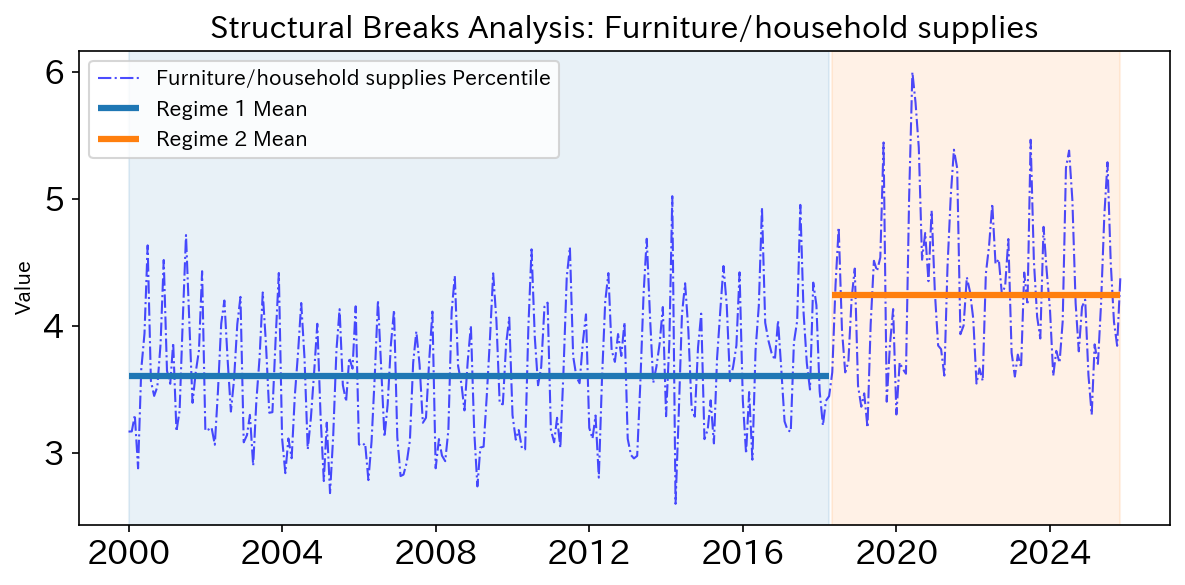

clothing and footwear
========== 【CLOTHING AND FOOTWEAR】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.7190
结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。

[2] 结构突变检测结果:
检测到 2 次发生'回不去'的结构性突变，时间点分别在: 2007-07, 2019-08


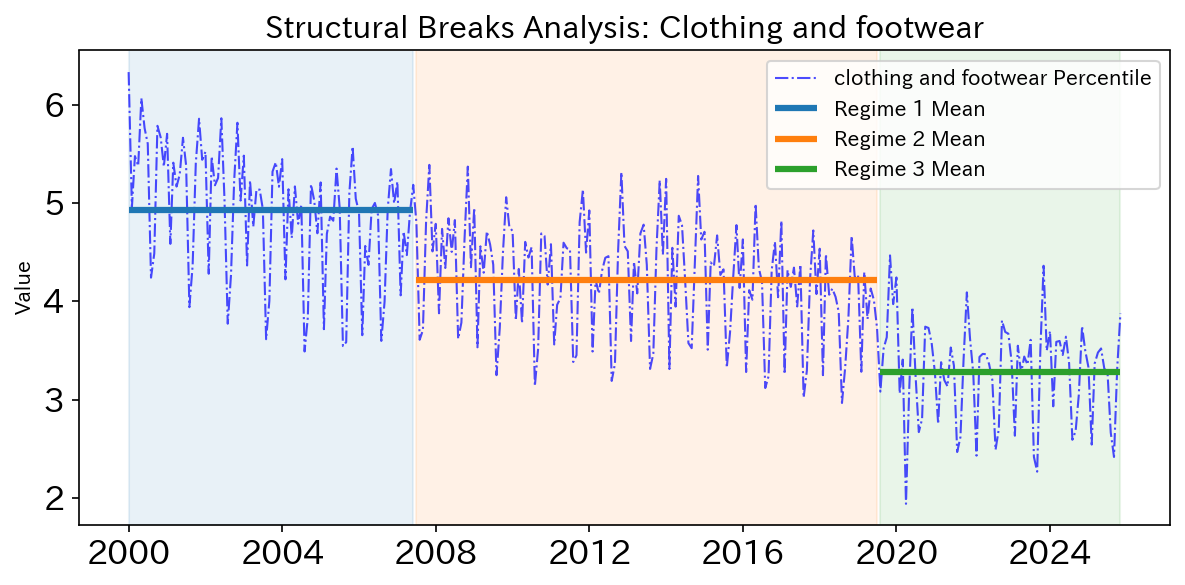

health care
========== 【HEALTH CARE】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.3833
结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。

[2] 结构突变检测结果:
检测到 1 次发生'回不去'的结构性突变，时间点分别在: 2019-08


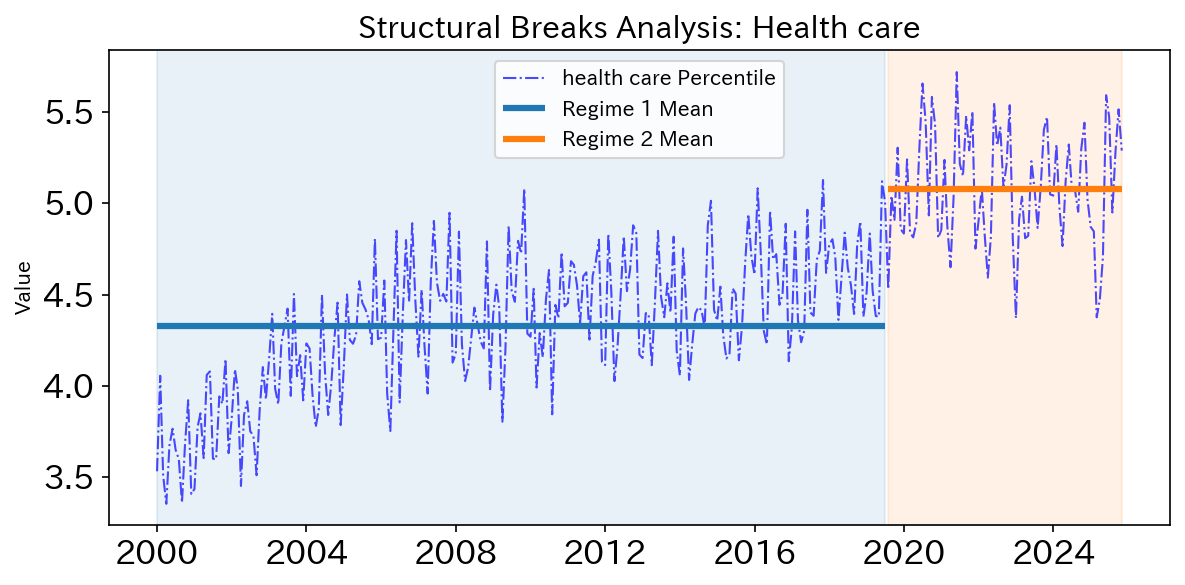

Transportation/Communication
========== 【TRANSPORTATION/COMMUNICATION】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.4345
结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。

[2] 结构突变检测结果:
检测到 2 次发生'回不去'的结构性突变，时间点分别在: 2004-03, 2012-02


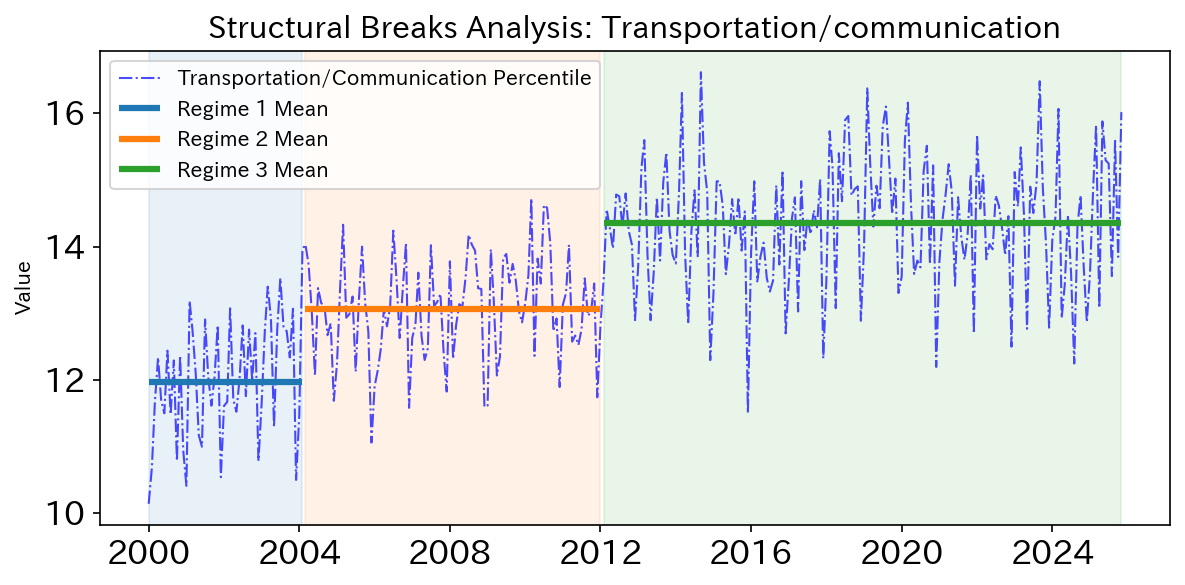

education
========== 【EDUCATION】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.0641
结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。

[2] 结构突变检测结果:
未检测到显著的结构性突变点。


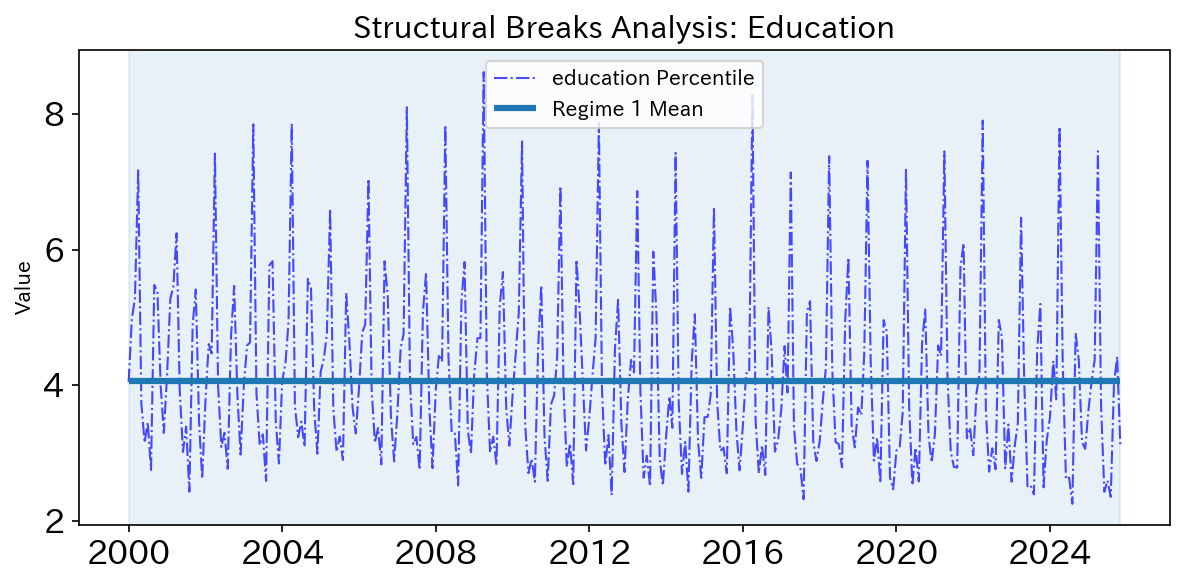

educational entertainment
========== 【EDUCATIONAL ENTERTAINMENT】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.5239
结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。

[2] 结构突变检测结果:
检测到 2 次发生'回不去'的结构性突变，时间点分别在: 2020-01, 2022-07


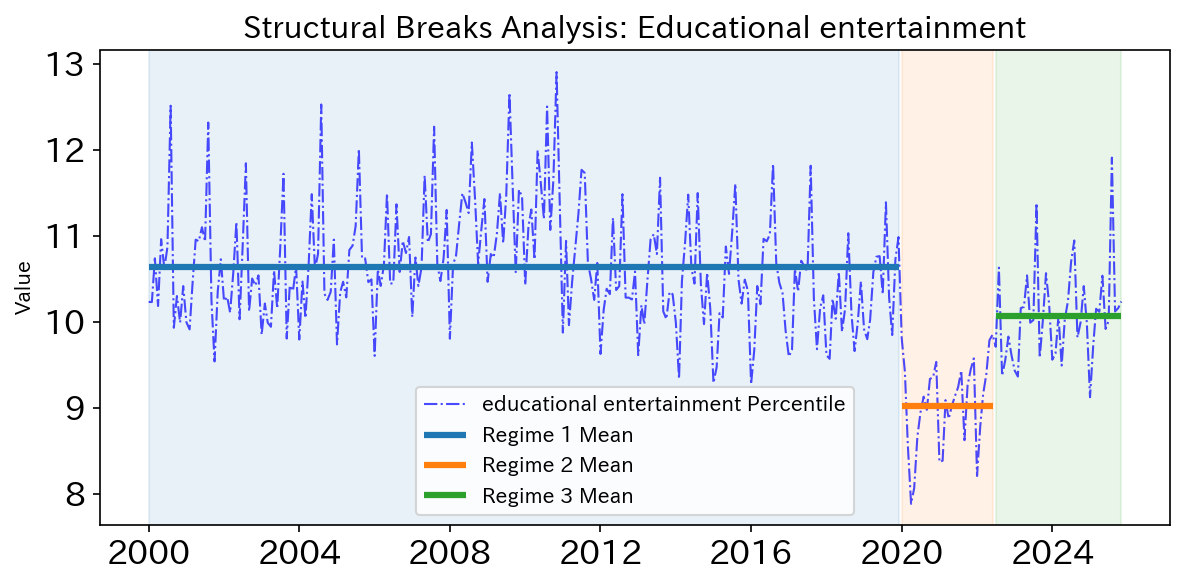

Other consumption expenditure
========== 【OTHER CONSUMPTION EXPENDITURE】 结构演变分析 ==========

[1] ADF 平稳性检验结果:
p-value: 0.9864
结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。

[2] 结构突变检测结果:
检测到 4 次发生'回不去'的结构性突变，时间点分别在: 2008-05, 2013-05, 2018-05, 2022-07


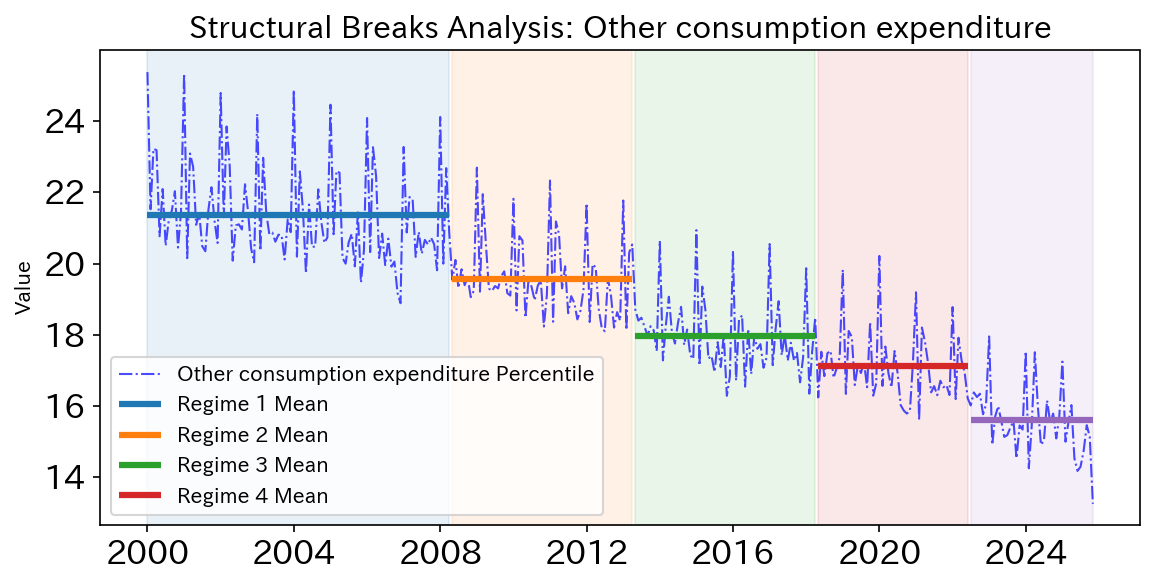

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import ruptures as rpt

def analyze_structural_changes(df_clean, category):
    """
    对单一消费类别进行平稳性检验与结构突变检测
    """
    # 0. 数据准备
    df = df_clean.copy()
    if 'Item' in df.columns:
        df['Item'] = pd.to_datetime(df['Item'])
        df.set_index('Item', inplace=True)
        
    series = df[category].dropna()
    
    print(f"========== 【{category.upper()}】 结构演变分析 ==========")
    
    # ---------------------------------------------------------
    # 1. 回答猜想一：定常状态存不存在？ (ADF 检验)
    # ---------------------------------------------------------
    # H0 (原假设): 存在单位根（非平稳，不存在定常状态，冲击会累积）
    # H1 (备择假设): 数据是平稳的（存在定常状态，冲击会被缓和）
    adf_result = adfuller(series, autolag='AIC')
    p_value = adf_result[1]
    
    print("\n[1] ADF 平稳性检验结果:")
    print(f"p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("结论: 拒绝原假设。数据是【平稳的】。系统存在定常状态，之前的'缓和时间'假设大概率成立。")
    else:
        print("结论: 无法拒绝原假设。数据是【非平稳的】（带有单位根）。系统不存在永远固定的均值，冲击会被永久累积或发生结构改变。")

    # ---------------------------------------------------------
    # 2. 回答猜想二与三：寻找突变点 (Ruptures PELT 算法)
    # ---------------------------------------------------------
    # 将 pandas series 转为 numpy array
    signal = series.values.reshape(-1, 1)
    
    # 使用 PELT 算法寻找均值突变点 (model="l2" 寻找均值跳跃)
    # pen 是惩罚系数，数值越大找出的突变点越少，可根据数据敏感度调整
    algo = rpt.Pelt(model="l2").fit(signal)
    result_breakpoints = algo.predict(pen=15)
    
    # 打印突变点对应的时间
    print("\n[2] 结构突变检测结果:")
    break_dates = []
    for idx in result_breakpoints[:-1]: # 最后一个是数据结尾，忽略
        date_str = series.index[idx].strftime('%Y-%m')
        break_dates.append(date_str)
    
    if len(break_dates) > 0:
        print(f"检测到 {len(break_dates)} 次发生'回不去'的结构性突变，时间点分别在: {', '.join(break_dates)}")
    else:
        print("未检测到显著的结构性突变点。")

    # ---------------------------------------------------------
    # 3. 可视化：看突变与累积是否同时存在
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
    
    # 画原始数据
    ax.plot(series.index, series.values, label=f'{category} Percentile', 
            color='blue', linewidth=1, linestyle='-.', alpha=0.7)
    
    # 画突变区间及分段均值
    start_idx = 0
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for i, bp in enumerate(result_breakpoints):
        end_idx = bp - 1 if bp < len(series) else len(series) - 1
        
        segment_data = series.iloc[start_idx:end_idx]
        segment_mean = segment_data.mean()
        
        # 填充背景色区分不同 Regime (状态)
        ax.axvspan(series.index[start_idx], series.index[end_idx], 
                   color=colors[i % len(colors)], alpha=0.1)
        
        # 画出这段时间内的“局部均值线” (代表这一个 Regime 的稳态)
        ax.hlines(y=segment_mean, xmin=series.index[start_idx], xmax=series.index[end_idx], 
                  color=colors[i % len(colors)], linewidth=3, linestyle='-', 
                  label=f'Regime {i+1} Mean' if i < 4 else "") # 限制图例数量
        
        start_idx = bp
        
    ax.set_title(f'Structural Breaks Analysis: {category.capitalize()}', fontsize=15, fontweight='bold')
    ax.set_ylabel('Value')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

# 调用示例：
for cat in final_df['Category'].unique():
    print(cat)
    analyze_structural_changes(df_clean, cat)

========== 【FOOD】 累积效应分析 ==========
初始理论值 (2000年): 24.1411
每月累积变化率 (斜率 β): 0.016504 (p-value: 8.8369e-40)

结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。

[去趋势后] 的 ADF 平稳性检验 p-value: 0.1513
结论 2: 即使去除了趋势，数据依然非平稳，说明其中可能还夹杂着真正的'结构性突变'。


/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages

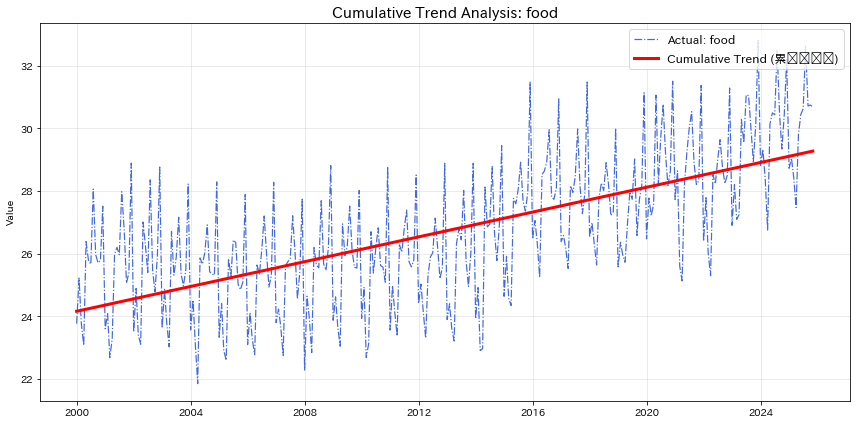

========== 【RESIDENCE】 累积效应分析 ==========
初始理论值 (2000年): 6.3506
每月累积变化率 (斜率 β): -0.000930 (p-value: 4.0208e-02)

结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。

[去趋势后] 的 ADF 平稳性检验 p-value: 0.1913
结论 2: 即使去除了趋势，数据依然非平稳，说明其中可能还夹杂着真正的'结构性突变'。


/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages

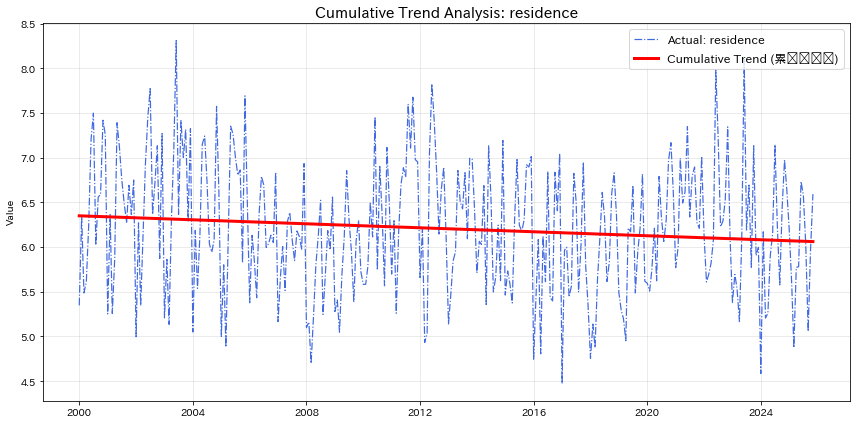

/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()


========== 【UTILITIES/WATER】 累积效应分析 ==========
初始理论值 (2000年): 7.0928
每月累积变化率 (斜率 β): 0.003231 (p-value: 1.2180e-04)

结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。

[去趋势后] 的 ADF 平稳性检验 p-value: 0.0045
结论 2: 去除长期累积趋势后，数据是【平稳的】。
最终判定: 这是一条带有坡度的单向轨迹 (Trend-Stationary)。之前的'阶梯'图是算法强制拟合平线造成的假象。


/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


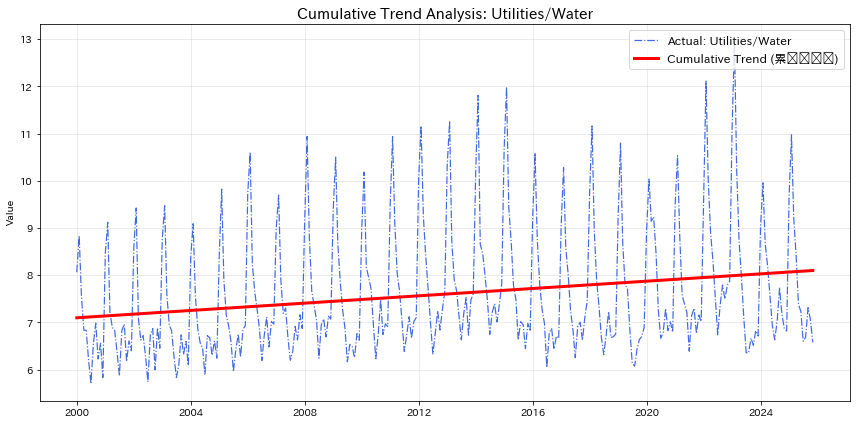

/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()


========== 【FURNITURE/HOUSEHOLD SUPPLIES】 累积效应分析 ==========
初始理论值 (2000年): 3.3303
每月累积变化率 (斜率 β): 0.002970 (p-value: 3.4753e-16)

结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。

[去趋势后] 的 ADF 平稳性检验 p-value: 0.0559
结论 2: 即使去除了趋势，数据依然非平稳，说明其中可能还夹杂着真正的'结构性突变'。


/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


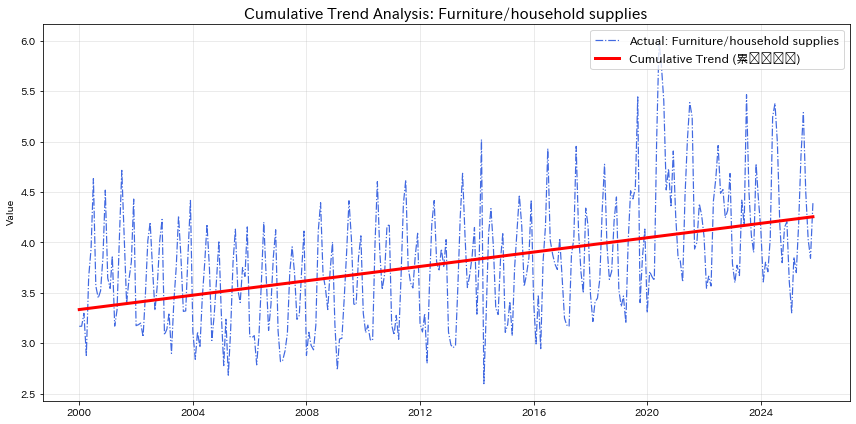

/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()


========== 【CLOTHING AND FOOTWEAR】 累积效应分析 ==========
初始理论值 (2000年): 5.2439
每月累积变化率 (斜率 β): -0.006714 (p-value: 2.4334e-53)

结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。

[去趋势后] 的 ADF 平稳性检验 p-value: 0.2315
结论 2: 即使去除了趋势，数据依然非平稳，说明其中可能还夹杂着真正的'结构性突变'。


/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


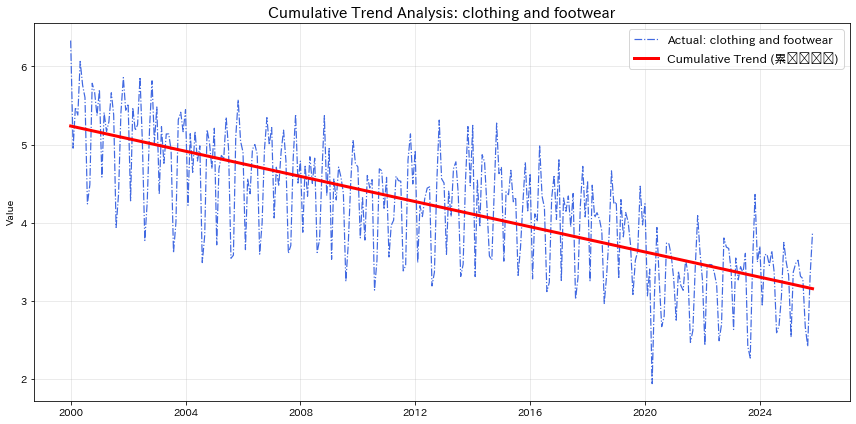

/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()


========== 【HEALTH CARE】 累积效应分析 ==========
初始理论值 (2000年): 3.8506
每月累积变化率 (斜率 β): 0.004254 (p-value: 2.2590e-66)

结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。

[去趋势后] 的 ADF 平稳性检验 p-value: 0.0216
结论 2: 去除长期累积趋势后，数据是【平稳的】。
最终判定: 这是一条带有坡度的单向轨迹 (Trend-Stationary)。之前的'阶梯'图是算法强制拟合平线造成的假象。


/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


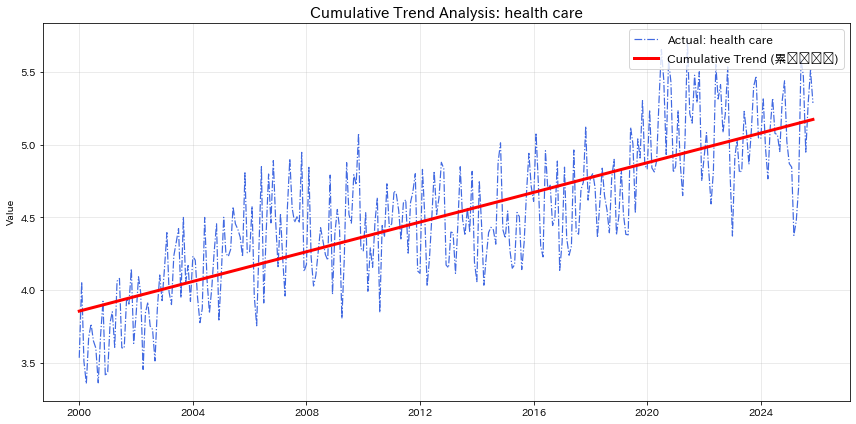

========== 【TRANSPORTATION/COMMUNICATION】 累积效应分析 ==========
初始理论值 (2000年): 12.1288
每月累积变化率 (斜率 β): 0.009347 (p-value: 4.2021e-41)

结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。

[去趋势后] 的 ADF 平稳性检验 p-value: 0.0343
结论 2: 去除长期累积趋势后，数据是【平稳的】。
最终判定: 这是一条带有坡度的单向轨迹 (Trend-Stationary)。之前的'阶梯'图是算法强制拟合平线造成的假象。


/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages

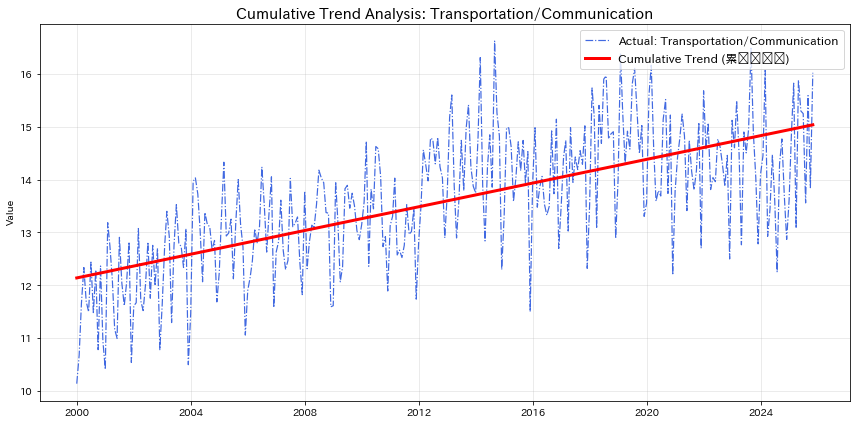

/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()


========== 【EDUCATION】 累积效应分析 ==========
初始理论值 (2000年): 4.3812
每月累积变化率 (斜率 β): -0.002027 (p-value: 1.7844e-02)

结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。

[去趋势后] 的 ADF 平稳性检验 p-value: 0.0003
结论 2: 去除长期累积趋势后，数据是【平稳的】。
最终判定: 这是一条带有坡度的单向轨迹 (Trend-Stationary)。之前的'阶梯'图是算法强制拟合平线造成的假象。


/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


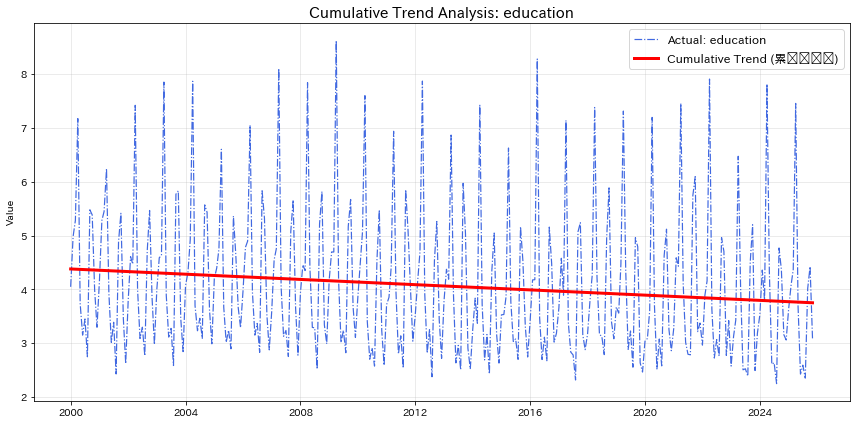

/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()


========== 【EDUCATIONAL ENTERTAINMENT】 累积效应分析 ==========
初始理论值 (2000年): 10.9938
每月累积变化率 (斜率 β): -0.003712 (p-value: 1.1127e-14)

结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。

[去趋势后] 的 ADF 平稳性检验 p-value: 0.2611
结论 2: 即使去除了趋势，数据依然非平稳，说明其中可能还夹杂着真正的'结构性突变'。


/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


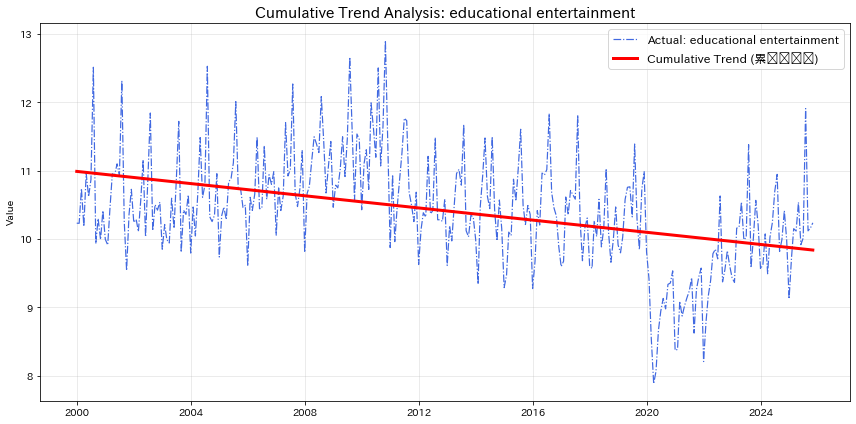

/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  plt.tight_layout()
/var/folders/nh/_9rm2h3d0pl30936qtz5c83m0000gn/T/ipykernel_99432/2574580001.py:66: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()


========== 【OTHER CONSUMPTION EXPENDITURE】 累积效应分析 ==========
初始理论值 (2000年): 22.4869
每月累积变化率 (斜率 β): -0.022924 (p-value: 1.2642e-99)

结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。

[去趋势后] 的 ADF 平稳性检验 p-value: 0.0114
结论 2: 去除长期累积趋势后，数据是【平稳的】。
最终判定: 这是一条带有坡度的单向轨迹 (Trend-Stationary)。之前的'阶梯'图是算法强制拟合平线造成的假象。


/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


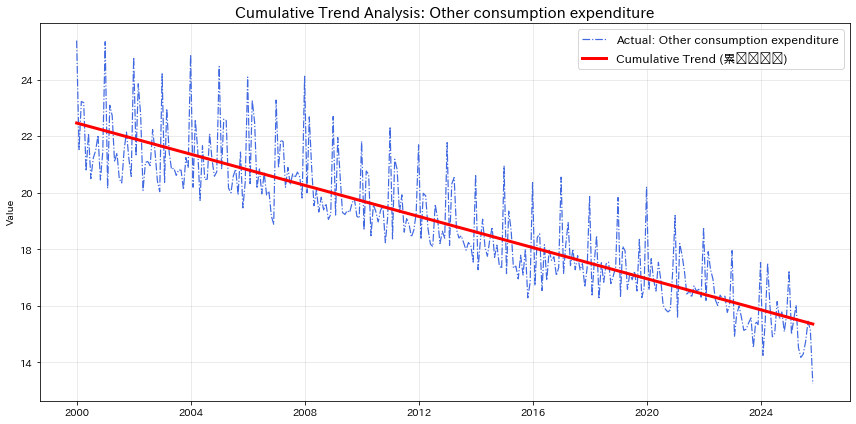

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

def test_cumulative_trend(df_clean, category):
    """
    验证消费占比是否存在长期的“累积效应”（时间趋势）
    """
    # 0. 准备数据
    df = df_clean.copy()
    if 'Item' in df.columns:
        df['Item'] = pd.to_datetime(df['Item'])
        df.set_index('Item', inplace=True)
        
    series = df[category].dropna()
    
    # 1. 构建时间变量 t (1, 2, 3, ..., N)
    t = np.arange(1, len(series) + 1)
    
    # 构建 OLS 回归模型: Y = alpha + beta * t
    X = sm.add_constant(t) 
    model = sm.OLS(series.values, X)
    results = model.fit()
    
    alpha = results.params[0] # 截距 (初始状态)
    beta = results.params[1]  # 斜率 (每月的累积效应)
    p_value_beta = results.pvalues[1] # 斜率的显著性
    
    print(f"========== 【{category.upper()}】 累积效应分析 ==========")
    print(f"初始理论值 (2000年): {alpha:.4f}")
    print(f"每月累积变化率 (斜率 β): {beta:.6f} (p-value: {p_value_beta:.4e})")
    
    if p_value_beta < 0.05:
        print("\n结论 1: 存在显著的长期累积趋势！系统并没有在某个均值上'缓和'，而是在随着时间推移产生永久性的偏移。")
    else:
        print("\n结论 1: 未发现显著的线性累积趋势。")

    # 2. 提取去除趋势后的残差，进行 ADF 检验
    residuals = results.resid
    adf_result = adfuller(residuals, autolag='AIC')
    adf_p_value = adf_result[1]
    
    print(f"\n[去趋势后] 的 ADF 平稳性检验 p-value: {adf_p_value:.4f}")
    if adf_p_value < 0.05:
        print("结论 2: 去除长期累积趋势后，数据是【平稳的】。")
        print("最终判定: 这是一条带有坡度的单向轨迹 (Trend-Stationary)。之前的'阶梯'图是算法强制拟合平线造成的假象。")
    else:
        print("结论 2: 即使去除了趋势，数据依然非平稳，说明其中可能还夹杂着真正的'结构性突变'。")

    # 3. 可视化：真实数据 vs 累积趋势线
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(series.index, series.values, label=f'Actual: {category}', color='#4169E1', linewidth=1.2, linestyle='-.')
    
    # 画出那条代表“累积效应”的斜线
    trend_line = alpha + beta * t
    ax.plot(series.index, trend_line, label='Cumulative Trend (累积趋势线)', color='red', linewidth=3)
    
    ax.set_title(f'Cumulative Trend Analysis: {category}', fontsize=15, fontweight='bold')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 调用示例：
for cat in final_df['Category'].unique():
    test_cumulative_trend(df_clean, cat)